### Langgraph with RAG

In [1]:
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings


llm=ChatGroq(model="llama-3.1-8b-instant")

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10581.56it/s]


In [2]:
llm.invoke("Hii").content

'Hello. How can I assist you today?'

In [4]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [5]:
loader=DirectoryLoader("../data",glob="./*.txt",loader_cls=TextLoader)

document=loader.load()

In [7]:
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=50
)
new_docs = text_splitter.split_documents(documents=document)
doc_strings = [doc.page_content for doc in new_docs]

In [8]:
doc_strings

['Agentic AI is a type of artificial intelligence that goes beyond just responding to user inputs and',
 'goes beyond just responding to user inputs and instead can independently plan, make decisions, and',
 'can independently plan, make decisions, and take actions to achieve a goal. Unlike traditional or',
 'actions to achieve a goal. Unlike traditional or generative AI systems that simply generate outputs',
 'AI systems that simply generate outputs when prompted, agentic AI systems operate in a loop of',
 'prompted, agentic AI systems operate in a loop of perceiving information, reasoning about it,',
 'of perceiving information, reasoning about it, executing tasks (like calling APIs or using tools),',
 'tasks (like calling APIs or using tools), and adapting based on results, allowing them to handle',
 'based on results, allowing them to handle complex, multi-step workflows with minimal human',
 'complex, multi-step workflows with minimal human intervention.']

In [9]:
db=Chroma.from_documents(new_docs,embeddings)

In [10]:
retriever=db.as_retriever(search_kwargs={"k":3})

In [14]:
query="What is Agentic AI"

docs=retriever.invoke(query)

In [15]:
docs

[Document(metadata={'source': '../data/demo.txt'}, page_content='Agentic AI is a type of artificial intelligence that goes beyond just responding to user inputs and'),
 Document(metadata={'source': '../data/demo.txt'}, page_content='prompted, agentic AI systems operate in a loop of perceiving information, reasoning about it,'),
 Document(metadata={'source': '../data/demo.txt'}, page_content='AI systems that simply generate outputs when prompted, agentic AI systems operate in a loop of')]

In [17]:
print(docs[0].metadata)
print(docs[0].page_content)

for doc in docs:
    print(doc)

{'source': '../data/demo.txt'}
Agentic AI is a type of artificial intelligence that goes beyond just responding to user inputs and
page_content='Agentic AI is a type of artificial intelligence that goes beyond just responding to user inputs and' metadata={'source': '../data/demo.txt'}
page_content='prompted, agentic AI systems operate in a loop of perceiving information, reasoning about it,' metadata={'source': '../data/demo.txt'}
page_content='AI systems that simply generate outputs when prompted, agentic AI systems operate in a loop of' metadata={'source': '../data/demo.txt'}


In [25]:
class AgentState():
    messages:[]



In [26]:
AgentState

__main__.AgentState

In [35]:
## LLM tool

def function1(AgentState):
    message=AgentState["messages"]
    question=message[-1]
    complete_prompt="Your task is to provide only the brief answer based on the user query. \
        Don't include too much reasoning. Following is the user query: " + question
    
    response=llm.invoke(complete_prompt)

    AgentState["messages"].append(response.content)

    return AgentState

In [36]:
## RAG tool

def function2(AgentState):
    message=AgentState["messages"]
    question=message[0]
    
    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """

    prompt=ChatPromptTemplate.from_template(template)

    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
        )
        
    result = retrieval_chain.invoke(question)
    return {"messages":[result]}



In [37]:
from langgraph.graph import StateGraph

workflow3=StateGraph(AgentState)

In [38]:
workflow3.add_node("LLM",function1)
workflow3.add_node("RAGtool",function2)

workflow3.add_edge("LLM","RAGtool")

workflow3.set_entry_point("LLM")
workflow3.set_finish_point("RAGtool")


In [39]:
app=workflow3.compile()

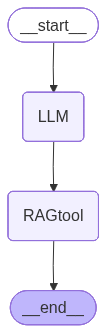

In [40]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [44]:
app.invoke({"messages":["What is Agentic AI"]})["messages"][0]

'Agentic AI is a type of artificial intelligence that goes beyond just responding to user inputs and prompted interactions, operating in a loop of perceiving information, reasoning about it, and likely taking further action.'

### Conditional Workflow

In [51]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [52]:
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings


llm=ChatGroq(model="llama-3.1-8b-instant")

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7935.29it/s]


In [53]:
loader=DirectoryLoader("../data2",glob="./*.txt",loader_cls=TextLoader)

document=loader.load()

text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=50
)
new_docs = text_splitter.split_documents(documents=document)
doc_strings = [doc.page_content for doc in new_docs]

In [54]:
db=Chroma.from_documents(new_docs,embeddings)
retriever=db.as_retriever(search_kwargs={"k":3})

In [57]:
query="Tell me about India's Industrial Growth?"

docs=retriever.invoke(query)

In [58]:
docs

[Document(metadata={'source': '../data2/indian_economy.txt'}, page_content='India’s industrial growth has outpaced expectations, raising hopes that the economy will avoid a'),
 Document(metadata={'source': '../data2/indian_economy.txt'}, page_content='Industrial Revival and Economic Optimism for India'),
 Document(metadata={'source': '../data2/indian_economy.txt'}, page_content='for India’s economy. “We are encouraged by the steady rise in domestic consumption and industrial')]

In [60]:
from typing import TypedDict, Annotated, Sequence
import operator
from langchain_core.messages import BaseMessage
from langchain_core.prompts import PromptTemplate

In [61]:
class AgentState(TypedDict):
    # The 'messages' field should be a sequence of strings, and we annotate it with 'operator.add'
    # This implies we might want to "add" new messages to the sequence later
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [62]:
from pydantic import BaseModel , Field
class TopicSelectionParser(BaseModel):
    Topic: str = Field(description='Selected Topic')
    Reasoning: str = Field(description='Reasoning behind topic selection')

In [64]:

from langchain_core.output_parsers import PydanticOutputParser
parser = PydanticOutputParser(pydantic_object=TopicSelectionParser)

In [65]:
parser.get_format_instructions()

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"Topic": {"description": "Selected Topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}\n```'

In [69]:
## Agent Tool

def function_1(state):
    message=state["messages"]
    question=message[-1]
    print(question)
    
    template = """
    Your task is to classify the given user query into one of the following categories: [India, Not Related].

    Respond ONLY in valid JSON format as per the instructions below.

    User query: {question}

    {format_instructions}
    """
    
    prompt = PromptTemplate(template=template,
                                    input_variables=[question],
                                    partial_variables={
                                        "format_instructions" : parser.get_format_instructions()                                    }
                                    )
    chain =  prompt | llm | parser
    
    response = chain.invoke({"question":question,"format_instructions" : parser.get_format_instructions() })

    print(response)

    return {"messages": [response.Topic]}

In [70]:

state={"messages": ["Tell me about India's Industrial Growth"]}

In [71]:
function_1(state)

Tell me about India's Industrial Growth
Topic='India' Reasoning="The query is about India's Industrial Growth, which relates to the topic of India"


{'messages': ['India']}

In [72]:
## defined for conditional workflow

def router(state):
    messages=state["messages"]
    last_message=messages[-1]

    print(last_message)

    if 'India' in last_message:
        return "RAG Call"
    else :
        return "LLM Call"

In [74]:
## RAG Tool

def function_2(state):
    print('-> Calling RAG ->')
    messages = state['messages']
    question = messages[0] ## Fetching the user question
    print(question)

    template = """Answer the question based only on the following context:
    {context}

    Question: {question}
    """
    prompt = ChatPromptTemplate.from_template(template)
    
    print(prompt)

    retrieval_chain = (
        {"context": retriever, "question": RunnablePassthrough()}
        | prompt
        | llm
        | StrOutputParser()
        )
    result = retrieval_chain.invoke(question)
    return  {"messages": [result]}

In [75]:
## LLM Tool

def function_3(state):
    print('-> Calling LLM ->')

    messages = state['messages']
    question = messages[0] ## Fetching the user question

    # Normal LLM call
    complete_query = "Anwer the follow question with your knowledge of the real world. Following is the user question: " + question
    response = llm.invoke(complete_query)
    return {"messages": [response.content]}

In [76]:
## Making workflow

from langgraph.graph import StateGraph,END

workflow4=StateGraph(AgentState)

In [77]:
workflow4.add_node("agent",function_1)
workflow4.add_node("RAG",function_2)
workflow4.add_node("LLM",function_3)


In [78]:
workflow4.set_entry_point("agent")

In [79]:
## setting up conditional edges

workflow4.add_conditional_edges(
    "agent",
    router,
    {
        "RAG Call":"RAG",
        "LLM Call":"LLM"
    }
)

In [80]:
workflow4.add_edge("RAG",END)
workflow4.add_edge("LLM",END)

In [81]:
app=workflow4.compile()

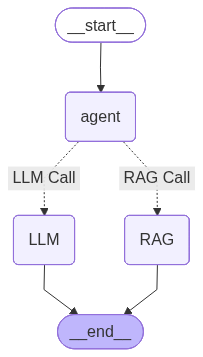

In [82]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    # This requires some extra dependencies and is optional
    print(e)

In [89]:
inputs = {"messages": ["Tell me about Prime minister of CHINA"]}

In [90]:
output=app.invoke(inputs)

Tell me about Prime minister of CHINA
Topic='Not Related' Reasoning='The query is about the Prime Minister of China, which is not related to India.'
Not Related
-> Calling LLM ->


In [91]:
output

{'messages': ['Tell me about Prime minister of CHINA',
  'Not Related',
  'As of my knowledge cutoff in 2023, the current Prime Minister of China is not a position, as China is a one-party state with a President as the head of state and the General Secretary of the Communist Party of China (CPC) as the head of the party. However, there are some key roles and positions that play a crucial role in the Chinese government.\n\nThe current leader of China is:\n\n1. **Xi Jinping**: He is the General Secretary of the Communist Party of China, the President of the People\'s Republic of China, and the Chairman of the Central Military Commission. He has been in power since 2013 and has consolidated his position by removing term limits for the President in 2018.\n\nThe Premier of the State Council, which is the chief administrative authority of the People\'s Republic of China, is:\n\n1. **Li Qiang**: He is the current Premier of the State Council of China, appointed in March 2023. He has been a ke